In [1]:
import torch
import numpy as np
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

from opimizers.adamuon import AdaMuon
from opimizers.muon import Muon

device = "xpu" if torch.xpu.is_available() else "cpu"
print(device)

%config InlineBackend.figure_format = 'svg'

xpu


In [2]:
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.xpu.is_available():
        torch.xpu.manual_seed(seed)

In [3]:
class ResNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()

    def forward(self, x):
        return F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))) + self.skip(x))

In [4]:
class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1, bias=False),
                                  nn.BatchNorm2d(32), nn.ReLU())
        self.layer1 = ResNetBlock(32, 64, stride=2)
        self.layer2 = ResNetBlock(64, 128, stride=2)
        self.layer3 = ResNetBlock(128, 256, stride=2)
        self.head = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.mean(dim=(2, 3))
        return self.head(x)

In [ ]:
def make_muon_optimizer(model, lr=1e-3):
    muon_params = [p for p in model.parameters()
                   if p.ndim >= 2 and p.requires_grad]
    adam_params = [p for p in model.parameters()
                   if p.ndim < 2 and p.requires_grad]
    return Muon([
        {"params": muon_params, "use_muon": True, "lr": lr},
        {"params": adam_params, "use_muon": False, "lr": lr},
    ])


def make_adamuon_optimizer(model, lr=1e-3):
    muon_params = [p for p in model.parameters()
                   if p.ndim >= 2 and p.requires_grad]
    adam_params = [p for p in model.parameters()
                   if p.ndim < 2 and p.requires_grad]
    return AdaMuon([
        {"params": muon_params, "use_muon": True, "lr": lr},
        {"params": adam_params, "use_muon": False, "lr": lr},
    ])


def make_adamuon_wo_sign_optimizer(model, lr=1e-3):
    muon_params = [p for p in model.parameters()
                   if p.ndim >= 2 and p.requires_grad]
    adam_params = [p for p in model.parameters()
                   if p.ndim < 2 and p.requires_grad]
    return AdaMuon([
        {"params": muon_params, "use_muon": True, "lr": lr, "use_sign": False},
        {"params": adam_params, "use_muon": False, "lr": lr},
    ])


def make_adam_optimizer(model, lr=1e-3):
    return torch.optim.AdamW(model.parameters(), lr=lr,
                             betas=(0.9, 0.95))

In [6]:
def get_cifar10(batch_size=128):
    tfm_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    tfm_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    train = datasets.CIFAR10(
        "data", train=True,  download=True, transform=tfm_train)
    test = datasets.CIFAR10("data", train=False,
                            download=True, transform=tfm_test)
    return (DataLoader(train, batch_size=batch_size, shuffle=True,
                       num_workers=2, pin_memory=True),
            DataLoader(test,  batch_size=256, shuffle=False,
                       num_workers=2, pin_memory=True))

In [7]:
def get_cifar100(batch_size=128):
    tfm_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    tfm_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
    ])
    train = datasets.CIFAR100(
        "data", train=True,  download=True, transform=tfm_train)
    test = datasets.CIFAR100("data", train=False,
                             download=True, transform=tfm_test)
    return (DataLoader(train, batch_size=batch_size, shuffle=True,
                       num_workers=2, pin_memory=True),
            DataLoader(test,  batch_size=256, shuffle=False,
                       num_workers=2, pin_memory=True))

In [8]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, n = 0., 0, 0
    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        res = model(x)
        loss = F.cross_entropy(res, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (res.argmax(1) == y).sum().item()
        n += len(y)
    return total_loss / n, correct / n

In [9]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, n = 0, 0
    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        n += len(y)
    return correct / n

In [20]:
dispatcher = {
    "muon": make_muon_optimizer,
    "adamuon": make_adamuon_optimizer,
    "adamuon_without_sign": make_adamuon_wo_sign_optimizer,
    "adam": make_adam_optimizer,
}

In [21]:
def run(optimizer_name, num_classes=10, epochs=20, device="cpu"):
    set_seed(42)
    if num_classes == 10:
        train_loader, test_loader = get_cifar10()
    else:
        train_loader, test_loader = get_cifar100()
    model = ResNet(num_classes=num_classes).to(device)

    assert optimizer_name in dispatcher, f"Unknown optimizer: {optimizer_name}"
    optimizer = dispatcher[optimizer_name](model)

    history = {"train_loss": [], "test_acc": []}
    for epoch in range(epochs):
        loss, _ = train_one_epoch(model, train_loader, optimizer, device)
        acc = evaluate(model, test_loader, device)
        history["train_loss"].append(loss)
        history["test_acc"].append(acc)
        print(f"[{optimizer_name}] epoch {epoch+1:3d}/{epochs} "
              f"loss={loss:.4f}  test_acc={acc:.3f}")
    return history

In [24]:
EPOCHS = 15

In [25]:
hist_adamuon = run("adamuon", epochs=EPOCHS, device=device)

/home/matta/dev/xpu/xpu_env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
100%|██████████| 40/40 [00:01<00:00, 26.34it/s]


[adamuon] epoch   1/15 loss=1.3455  test_acc=0.632


100%|██████████| 40/40 [00:01<00:00, 28.24it/s]


[adamuon] epoch   2/15 loss=0.8690  test_acc=0.720


100%|██████████| 40/40 [00:01<00:00, 28.28it/s]


...

[adamuon] epoch  13/15 loss=0.2977  test_acc=0.867


100%|██████████| 40/40 [00:01<00:00, 25.98it/s]


[adamuon] epoch  14/15 loss=0.2831  test_acc=0.865


100%|██████████| 40/40 [00:01<00:00, 29.97it/s]

[adamuon] epoch  15/15 loss=0.2691  test_acc=0.866


In [14]:
hist_muon = run("muon", epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 28.14it/s]


[muon] epoch   1/15 loss=1.2715  test_acc=0.672


100%|██████████| 40/40 [00:01<00:00, 28.64it/s]


[muon] epoch   2/15 loss=0.7762  test_acc=0.756


100%|██████████| 40/40 [00:01<00:00, 27.51it/s]


...

[muon] epoch  13/15 loss=0.2474  test_acc=0.872


100%|██████████| 40/40 [00:01<00:00, 27.48it/s]


[muon] epoch  14/15 loss=0.2319  test_acc=0.871


100%|██████████| 40/40 [00:01<00:00, 28.48it/s]

[muon] epoch  15/15 loss=0.2214  test_acc=0.875


In [15]:
hist_adam = run("adam", epochs=EPOCHS, device=device)

/home/matta/dev/xpu/xpu_env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
100%|██████████| 40/40 [00:01<00:00, 28.42it/s]


[adam] epoch   1/15 loss=1.3506  test_acc=0.609


100%|██████████| 40/40 [00:01<00:00, 25.45it/s]


[adam] epoch   2/15 loss=0.9582  test_acc=0.629


100%|██████████| 40/40 [00:01<00:00, 28.15it/s]


...

[adam] epoch  13/15 loss=0.3701  test_acc=0.841


100%|██████████| 40/40 [00:01<00:00, 29.03it/s]


[adam] epoch  14/15 loss=0.3554  test_acc=0.840


100%|██████████| 40/40 [00:01<00:00, 26.80it/s]

[adam] epoch  15/15 loss=0.3478  test_acc=0.847


In [ ]:
hist_adamuon_wo_sign = run("adamuon_without_sign",
                           epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 27.86it/s]


[adamuon_without_sign] epoch   1/15 loss=1.2766  test_acc=0.676


100%|██████████| 40/40 [00:01<00:00, 27.49it/s]


[adamuon_without_sign] epoch   2/15 loss=0.7800  test_acc=0.762


100%|██████████| 40/40 [00:01<00:00, 27.38it/s]


...

[adamuon_without_sign] epoch  13/15 loss=0.2438  test_acc=0.874


100%|██████████| 40/40 [00:01<00:00, 27.53it/s]


[adamuon_without_sign] epoch  14/15 loss=0.2331  test_acc=0.880


100%|██████████| 40/40 [00:01<00:00, 30.20it/s]

[adamuon_without_sign] epoch  15/15 loss=0.2201  test_acc=0.878


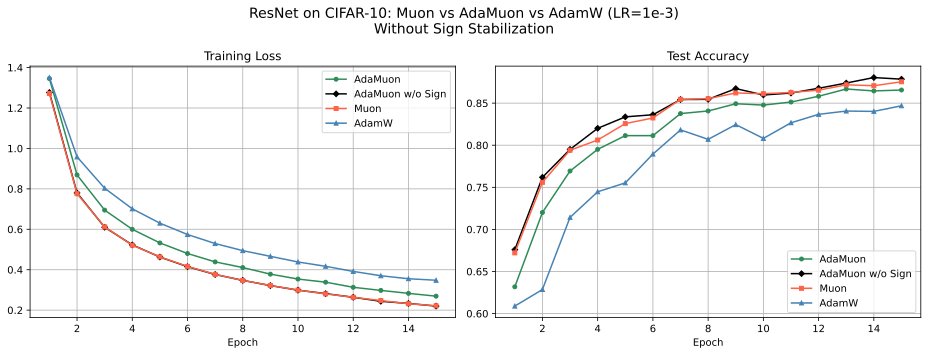

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

plt.suptitle(
    "ResNet on CIFAR-10: Muon vs AdaMuon vs AdamW (LR=1e-3)\nWithout Sign Stabilization", fontsize=14)

x = np.arange(1, EPOCHS + 1)

ax1.plot(x, hist_adamuon["train_loss"], label="AdaMuon",
         color='seagreen', marker='o', markersize=4)
ax1.plot(x, hist_adamuon_wo_sign["train_loss"], label="AdaMuon w/o Sign",
         color='black', marker='D', markersize=4)
ax1.plot(x, hist_muon["train_loss"], label="Muon",
         color='tomato', marker='s', markersize=4)
ax1.plot(x, hist_adam["train_loss"], label="AdamW",
         color='steelblue', marker='^', markersize=4)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.grid()
ax1.legend()

ax2.plot(x, hist_adamuon["test_acc"], label="AdaMuon",
         color='seagreen', marker='o', markersize=4)
ax2.plot(x, hist_adamuon_wo_sign["test_acc"], label="AdaMuon w/o Sign",
         color='black', marker='D', markersize=4)
ax2.plot(x, hist_muon["test_acc"], label="Muon",
         color='tomato', marker='s', markersize=4)
ax2.plot(x, hist_adam["test_acc"], label="AdamW",
         color='steelblue', marker='^', markersize=4)
ax2.set_title("Test Accuracy")
ax2.set_xlabel("Epoch")
ax2.grid()
ax2.legend()

plt.tight_layout()

In [28]:
EPOCHS = 30

In [29]:
hist_adamuon_100 = run("adamuon", num_classes=100,
                       epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 27.56it/s]


[adamuon] epoch   1/30 loss=3.6077  test_acc=0.265


100%|██████████| 40/40 [00:01<00:00, 27.64it/s]


[adamuon] epoch   2/30 loss=2.6912  test_acc=0.366


100%|██████████| 40/40 [00:01<00:00, 29.08it/s]


...

[adamuon] epoch  28/30 loss=0.5961  test_acc=0.625


100%|██████████| 40/40 [00:01<00:00, 28.04it/s]


[adamuon] epoch  29/30 loss=0.5740  test_acc=0.625


100%|██████████| 40/40 [00:01<00:00, 28.10it/s]

[adamuon] epoch  30/30 loss=0.5592  test_acc=0.624


In [30]:
hist_muon_100 = run("muon", num_classes=100, epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 27.69it/s]


[muon] epoch   1/30 loss=3.4473  test_acc=0.311


100%|██████████| 40/40 [00:01<00:00, 27.79it/s]


[muon] epoch   2/30 loss=2.4282  test_acc=0.429


100%|██████████| 40/40 [00:01<00:00, 27.95it/s]


...

[muon] epoch  28/30 loss=0.4430  test_acc=0.642


100%|██████████| 40/40 [00:01<00:00, 27.55it/s]


[muon] epoch  29/30 loss=0.4247  test_acc=0.638


100%|██████████| 40/40 [00:01<00:00, 27.75it/s]

[muon] epoch  30/30 loss=0.4072  test_acc=0.640


In [31]:
hist_adam_100 = run("adam", num_classes=100, epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 28.42it/s]


[adam] epoch   1/30 loss=3.5993  test_acc=0.217


100%|██████████| 40/40 [00:01<00:00, 27.96it/s]


[adam] epoch   2/30 loss=2.8418  test_acc=0.302


100%|██████████| 40/40 [00:01<00:00, 28.00it/s]


...

[adam] epoch  28/30 loss=0.7612  test_acc=0.616


100%|██████████| 40/40 [00:01<00:00, 27.82it/s]


[adam] epoch  29/30 loss=0.7422  test_acc=0.606


100%|██████████| 40/40 [00:01<00:00, 28.16it/s]

[adam] epoch  30/30 loss=0.7129  test_acc=0.612


In [ ]:
hist_adamuon_wo_sign_100 = run(
    "adamuon_without_sign", num_classes=100, epochs=EPOCHS, device=device)

100%|██████████| 40/40 [00:01<00:00, 27.45it/s]


[adamuon_without_sign] epoch   1/30 loss=3.4600  test_acc=0.316


100%|██████████| 40/40 [00:01<00:00, 27.88it/s]


[adamuon_without_sign] epoch   2/30 loss=2.4252  test_acc=0.428


100%|██████████| 40/40 [00:01<00:00, 27.55it/s]


...

[adamuon_without_sign] epoch  28/30 loss=0.4342  test_acc=0.646


100%|██████████| 40/40 [00:01<00:00, 26.72it/s]


[adamuon_without_sign] epoch  29/30 loss=0.4186  test_acc=0.646


100%|██████████| 40/40 [00:01<00:00, 26.80it/s]

[adamuon_without_sign] epoch  30/30 loss=0.3992  test_acc=0.643


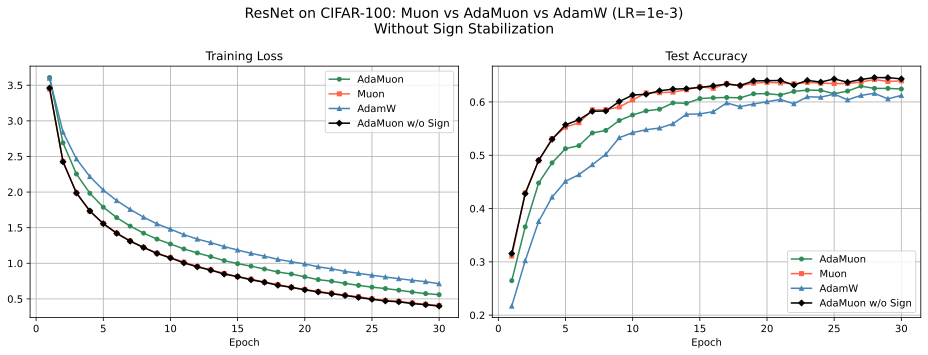

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

plt.suptitle(
    "ResNet on CIFAR-100: Muon vs AdaMuon vs AdamW (LR=1e-3)\nWithout Sign Stabilization", fontsize=14)

x = np.arange(1, EPOCHS + 1)

ax1.plot(x, hist_adamuon_100["train_loss"], label="AdaMuon",
         color='seagreen', marker='o', markersize=4)
ax1.plot(x, hist_muon_100["train_loss"], label="Muon",
         color='tomato', marker='s', markersize=4)
ax1.plot(x, hist_adam_100["train_loss"], label="AdamW",
         color='steelblue', marker='^', markersize=4)
ax1.plot(x, hist_adamuon_wo_sign_100["train_loss"], label="AdaMuon w/o Sign",
         color='black', marker='D', markersize=4)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.grid()
ax1.legend()

ax2.plot(x, hist_adamuon_100["test_acc"], label="AdaMuon",
         color='seagreen', marker='o', markersize=4)
ax2.plot(x, hist_muon_100["test_acc"], label="Muon",
         color='tomato', marker='s', markersize=4)
ax2.plot(x, hist_adam_100["test_acc"], label="AdamW",
         color='steelblue', marker='^', markersize=4)
ax2.plot(x, hist_adamuon_wo_sign_100["test_acc"], label="AdaMuon w/o Sign",
         color='black', marker='D', markersize=4)
ax2.set_title("Test Accuracy")
ax2.set_xlabel("Epoch")
ax2.grid()
ax2.legend()

plt.tight_layout()